# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = ["ASTROMORF", "ADAM", "NELDMD", "RNDSRCH", "STRONG", "ASTRODF"]
# problem_abbr_names = ["NETWORK-1", "ROSENBROCK-1", "SAN-1","DYNAMNEWS-1", "IRONORECONT-1", "SSCONT-1"]
problem_abbr_names = ["SAN-1", "NETWORK-1", "DYNAMNEWS-1", "ROSENBROCK-1", "SSCONT-1"]

num_macroreps = 5
num_postreps = 30
num_postreps_init_opt = 30 

In [3]:
# Function that instantiates a problem instance given its name and scales the dimension of the problem for a given dimension argument
from simopt.experiment_base import instantiate_problem, instantiate_solver, Problem, ProblemsSolvers, ProblemSolver
import numpy as np
import random
import hashlib

SCALABLE_PROBLEMS = ["FIXEDSAN-1", "NETWORK-1", "ROSENBROCK-1", "SAN-1", "DYNAMNEWS-1", "FACSIZE-2", "FACSIZE-1", "CONTAM-2"]

def scale_dimension(problem_name: str, budget: int, dimension: int | None = None) -> Problem:
    """
    Instantiate a problem with a scaled dimension.
    
    All model and problem factors that depend on the dimension are updated
    before instantiation to ensure consistency.
    
    Args:
        problem_name: The abbreviated name of the problem (e.g., "FACSIZE-2")
        dimension: The desired dimension for the problem
        
    Returns:
        A Problem instance configured for the specified dimension
    """
    if problem_name not in SCALABLE_PROBLEMS or dimension is None:
        # For non-scalable problems, just instantiate with defaults
        return instantiate_problem(problem_name, {'budget': budget})
    
    # Build the factors for the new dimension
    model_factors = get_scaled_model_factors(problem_name, dimension)
    problem_factors = get_scaled_problem_factors(problem_name, dimension)
    problem_factors['budget'] = budget
    
    # Instantiate the problem with the scaled factors
    problem = instantiate_problem(
        problem_name,
        problem_fixed_factors=problem_factors,
        model_fixed_factors=model_factors
    )
    
    # Set the problem dimension explicitly
    problem.dim = dimension
    
    # Post-initialization updates for factors that can't be validated during construction
    post_init_updates(problem, problem_name, dimension)
    
    return problem


def get_scaled_model_factors(problem_name: str, dimension: int) -> dict:
    """
    Generate model factors scaled to the specified dimension.
    
    Args:
        problem_name: The abbreviated name of the problem
        dimension: The target dimension
        
    Returns:
        Dictionary of model factors appropriate for the dimension
    """
    # Deterministic RNGs based on problem name + dimension
    seed = int(hashlib.sha256(f"{problem_name}:{dimension}".encode()).hexdigest(), 16) % (2**32)
    rng_py = random.Random(seed)
    rng_np = np.random.default_rng(seed)

    if problem_name == 'DYNAMNEWS-1':
        return {
            'num_prod': dimension,
            'c_utility': [float(6 + j) for j in range(dimension)],
            'init_level': [3] * dimension,
            'price': [9.0] * dimension,
            'cost': [5.0] * dimension,
        }
    
    elif problem_name in ('FACSIZE-1', 'FACSIZE-2'):
        # Use diagonal covariance to avoid expensive Cholesky and reduce rejection rate
        # With mean=500 and std=50 (variance=2500), P(X<0) ≈ 0 for each dimension
        # This makes rejection sampling nearly instant
        variance = 2500.0  # std = 50, mean = 500, so P(X<0) is negligible
        cov_matrix = np.eye(dimension) * variance
        return {
            'mean_vec': [500.0] * dimension,
            'cov': cov_matrix.tolist(),
            'capacity': [float(rng_py.randint(100, 900)) for _ in range(dimension)],
            'n_fac': dimension,
        }
    
    elif problem_name == 'SAN-1':
        # Calculate appropriate num_nodes for the number of edges (dimension)
        # For a DAG: we need num_nodes such that we can have 'dimension' edges
        # with a path from node 1 to num_nodes
        num_nodes = compute_num_nodes_for_dag(dimension)
        arcs = build_san_dag(num_nodes, dimension, rng=rng_py)
        return {
            'num_arcs': dimension,
            'num_nodes': num_nodes,
            'arcs': arcs,
            'arc_means': tuple(round(rng_py.uniform(1, 10), 2) for _ in range(dimension)),
        }
    
    elif problem_name == 'FIXEDSAN-1':
        num_nodes = max(2, rng_py.randint(2, max(2, dimension)))
        return {
            'num_arcs': dimension,
            'num_nodes': num_nodes,
            'arc_means': tuple(float(rng_py.randint(1, 10)) for _ in range(dimension)),
        }
    
    elif problem_name == 'ROSENBROCK-1':
        return {
            'x': (2.0,) * dimension,
            'variance': 0.4,
        }
    elif problem_name == 'ZAKHAROV-1':
        return {
            'x': (2.0,) * dimension,
            'variance': 0.1,
        }   
    
    elif problem_name == 'NETWORK-1':
        process_prob_elem = 1.0 / dimension
        mode_transit_time = [round(rng_py.uniform(0.01, 5), 3) for _ in range(dimension)]
        return {
            'process_prob': [process_prob_elem] * dimension,
            'cost_process': [0.1 / (x + 1) for x in range(dimension)],
            'cost_time': [round(rng_py.uniform(0.01, 1), 3) for _ in range(dimension)],
            'mode_transit_time': mode_transit_time,
            'lower_limits_transit_time': [x / 2 for x in mode_transit_time],
            'upper_limits_transit_time': [2 * x for x in mode_transit_time],
            'n_networks': dimension,
        }
    
    elif problem_name == 'CONTAM-2':
        return {
            'stages': dimension,
            'prev_decision': (0.0,) * dimension,
        }
    
    return {}


def get_scaled_problem_factors(problem_name: str, dimension: int) -> dict:
    """
    Generate problem factors scaled to the specified dimension.
    
    Only includes factors that will pass validation during construction.
    Factors that depend on model state are updated post-initialization.
    
    Args:
        problem_name: The abbreviated name of the problem
        dimension: The target dimension
        
    Returns:
        Dictionary of problem factors appropriate for the dimension
    """
    if problem_name == 'DYNAMNEWS-1':
        return {
            'initial_solution': (3.0,) * dimension,
        }
    
    elif problem_name in ('FACSIZE-1', 'FACSIZE-2'):
        # NOTE: installation_costs is validated against NUM_FACILITIES constant (=3)
        # So we can't pass it here - it will be updated post-initialization
        return {
            'initial_solution': (100.0,) * dimension,
            'installation_budget': 500.0 * (dimension / 3),  # Scale budget with dimension
        }
    
    elif problem_name in ('SAN-1', 'FIXEDSAN-1'):
        # NOTE: arc_costs is validated against NUM_ARCS constant (=13)
        # So we can't pass it here - it will be updated post-initialization
        return {
            'initial_solution': (1.0,) * dimension,
        }
    
    elif problem_name == 'ROSENBROCK-1':
        return {
            'initial_solution': (2.0,) * dimension,
        }
    
    elif problem_name == 'ZAKHAROV-1':
        return {
            'initial_solution': (2.0,) * dimension,
        }
    
    elif problem_name == 'NETWORK-1':
        return {
            'initial_solution': (1.0 / dimension,) * dimension,
        }
    
    elif problem_name == 'CONTAM-2':
        return {
            'initial_solution': (0.0,) * dimension,
        }
    
    return {}


def post_init_updates(problem: Problem, problem_name: str, dimension: int) -> None:
    """
    Update problem factors after initialization for factors that couldn't be set during construction.
    
    Some factors are validated against hardcoded constants during construction,
    so they need to be updated after the problem is instantiated.
    
    Args:
        problem: The problem instance to update
        problem_name: The abbreviated name of the problem
        dimension: The target dimension
    """
    if problem_name in ('FACSIZE-1', 'FACSIZE-2'):
        # Update installation_costs after construction to match the new dimension
        problem.factors['installation_costs'] = (1.0,) * dimension
    
    elif problem_name in ('SAN-1', 'FIXEDSAN-1'):
        # Update arc_costs after construction to match the new dimension
        # arc_costs is used in replicate(): np.sum(arc_costs / x)
        problem.factors['arc_costs'] = (1.0,) * dimension


def compute_num_nodes_for_dag(num_edges: int) -> int:
    """
    Compute an appropriate number of nodes for a DAG with the given number of edges.
    
    For a DAG with n nodes where we need a path from 1 to n:
    - Minimum edges needed: n-1 (a simple path)
    - Maximum edges possible: n*(n-1)/2 (complete DAG)
    
    We want to find the smallest n such that n*(n-1)/2 >= num_edges
    and n-1 <= num_edges (so we have enough edges for connectivity).
    
    Args:
        num_edges: Desired number of edges
        
    Returns:
        Number of nodes to use
    """
    # We need at least num_edges + 1 nodes in the worst case (simple path),
    # but we want fewer nodes with more edges between them.
    # Solve: n*(n-1)/2 >= num_edges => n^2 - n - 2*num_edges >= 0
    # n >= (1 + sqrt(1 + 8*num_edges)) / 2
    
    import math
    min_nodes = int(math.ceil((1 + math.sqrt(1 + 8 * num_edges)) / 2))
    
    # Ensure we have at least 2 nodes and the path is possible
    min_nodes = max(2, min_nodes)
    
    # Also ensure num_edges >= min_nodes - 1 (need at least a spanning path)
    # If not, we need more nodes
    while min_nodes - 1 > num_edges:
        min_nodes -= 1
    
    return min_nodes


def build_san_dag(num_nodes: int, num_edges: int, rng: random.Random | None = None) -> list[tuple[int, int]]:
    """
    Build a directed acyclic graph (DAG) suitable for the SAN model.
    
    The SAN model requires:
    1. Directed edges (arcs) from lower-numbered to higher-numbered nodes
    2. A path must exist from node 1 to node num_nodes
    3. Every node must be reachable from node 1 (for backtracking to work)
    
    This function first creates a simple sequential path from 1 to num_nodes
    (1→2→3→...→n), then adds additional random forward edges until reaching num_edges.
    
    Args:
        num_nodes: Number of nodes (numbered 1 to num_nodes)
        num_edges: Desired number of directed edges
        
    Returns:
        List of (source, target) tuples representing directed edges
        
    Raises:
        ValueError: If the requested configuration is impossible
    """
    min_edges = num_nodes - 1  # Simple path from 1 to num_nodes
    max_edges = num_nodes * (num_nodes - 1) // 2  # Complete DAG
    
    if num_edges < min_edges:
        raise ValueError(
            f"Cannot create DAG with path 1→{num_nodes}: need at least {min_edges} edges, "
            f"but only {num_edges} requested"
        )
    
    if num_edges > max_edges:
        raise ValueError(
            f"Cannot create DAG with {num_edges} edges: maximum possible is {max_edges} "
            f"for {num_nodes} nodes"
        )
    
    edges = set()
    
    # Step 1: Create a guaranteed SEQUENTIAL path from node 1 to node num_nodes
    # This ensures every node has a predecessor reachable from node 1
    # Path: 1 → 2 → 3 → ... → num_nodes
    for i in range(1, num_nodes):
        edges.add((i, i + 1))
    
    # Step 2: Add additional random forward edges until we reach num_edges
    if len(edges) < num_edges:
        if rng is None:
            rng = random
        # Generate all possible forward edges not yet in the graph
        all_possible_edges = []
        for i in range(1, num_nodes):
            for j in range(i + 1, num_nodes + 1):
                edge = (i, j)
                if edge not in edges:
                    all_possible_edges.append(edge)
        
        # Shuffle and add as many as needed
        rng.shuffle(all_possible_edges)
        edges_needed = num_edges - len(edges)
        
        for edge in all_possible_edges[:edges_needed]:
            edges.add(edge)
    
    return list(edges)


def validate_solver_and_problem_names(solver_name: str, problem_name: str) -> None:
    """Pre-flight validation for clearer errors before heavy work."""
    try:
        _ = instantiate_solver(solver_name=solver_name, fixed_factors={}, solver_rename=solver_name)
    except Exception as e:
        raise ValueError(f"Unknown or invalid solver code '{solver_name}'. Original error: {e}") from e

    try:
        _ = instantiate_problem(problem_name, problem_fixed_factors=None, model_fixed_factors=None)
    except Exception as e:
        raise ValueError(f"Unknown problem code '{problem_name}'. Original error: {e}") from e


def build_connected_graph(num_nodes: int, num_edges: int, rng: random.Random | None = None) -> list[tuple[int, int]]:
    """
    Build a connected graph with the specified number of nodes and edges.
    
    Starts with a spanning tree to ensure connectivity, then adds random edges
    until the desired number is reached.
    """
    if num_edges < num_nodes - 1:
        raise ValueError(f"Cannot create connected graph: need at least {num_nodes - 1} edges for {num_nodes} nodes")
    
    edges = set()
    
    if rng is None:
        rng = random

    # Create a spanning tree first to ensure connectivity
    nodes = list(range(num_nodes))
    rng.shuffle(nodes)
    for i in range(1, num_nodes):
        a = nodes[i]
        b = nodes[rng.randint(0, i - 1)]
        edges.add((min(a, b), max(a, b)))
    
    # Add random edges until we reach the desired number
    max_possible_edges = num_nodes * (num_nodes - 1) // 2
    target_edges = min(num_edges, max_possible_edges)
    
    attempts = 0
    max_attempts = target_edges * 10  # Prevent infinite loop
    while len(edges) < target_edges and attempts < max_attempts:
        a = rng.randint(0, num_nodes - 1)
        b = rng.randint(0, num_nodes - 1)
        if a != b:
            edges.add((min(a, b), max(a, b)))
        attempts += 1
    
    return list(edges)


In [4]:
# Determinism check: verify scaled model/problem factors are identical across repeated calls
# and do not vary by solver. This cell compares the outputs of the scaling helpers.

problems_to_check = problem_abbr_names
check_dim = 100

results = []
for pname in problems_to_check:
    if pname not in SCALABLE_PROBLEMS:
        results.append((pname, 'non-scalable', True, True))
        continue
    m1 = get_scaled_model_factors(pname, check_dim)
    p1 = get_scaled_problem_factors(pname, check_dim)
    model_ok = True
    prob_ok = True
    # Call the scaling helpers repeatedly and compare
    for _ in range(5):
        m2 = get_scaled_model_factors(pname, check_dim)
        p2 = get_scaled_problem_factors(pname, check_dim)
        if m1 != m2:
            model_ok = False
        if p1 != p2:
            prob_ok = False
    results.append((pname, check_dim, model_ok, prob_ok))

# Print a short summary
for r in results:
    print(f"{r[0]:15} dim={r[1]:>3} model_equal={r[2]} problem_equal={r[3]}")


SAN-1           dim=100 model_equal=True problem_equal=True
NETWORK-1       dim=100 model_equal=True problem_equal=True
DYNAMNEWS-1     dim=100 model_equal=True problem_equal=True
ROSENBROCK-1    dim=100 model_equal=True problem_equal=True
SSCONT-1        dim=non-scalable model_equal=True problem_equal=True


In [ ]:
#Dictionary for different subspace sizes for each problem (only used for ASTROMORF)
subspace_sizes = {
    "NETWORK-1": 40,
    "ROSENBROCK-1": 40,
    "ZAKHAROV-1": 5,
    "SAN-1": 40,
    "FIXEDSAN-1": 9,
    "DYNAMNEWS-1": 40,
    "FACSIZE-1": 5,
    "FACSIZE-2": 5,
    "CONTAM-2": 20,
    "IRONORECONT-1": 2,
    "SSCONT-1": 1,
}

problems = [] 
for problem_name in problem_abbr_names:
    problem = scale_dimension(problem_name, 10000, 100)
    problems.append(problem)

#Construct a list of lists of ProblemSolver instances to be the experiments argument in the ProblemsSolvers constructor
experiments = []
for solver_name in solver_abbr_names:
    ps_same_solver = []
    for problem in problems:
        if solver_name == "ASTROMORF":
            if problem.name in ['SSCONT-1', 'IRONORECONT-1']:
                solver_factors = {'crn_across_solns': False, 'initial subspace dimension': subspace_sizes[problem.name], 'polynomial degree': 2}
            else :
                solver_factors = {'crn_across_solns': False, 'initial subspace dimension': subspace_sizes[problem.name]}
            solver_rename = "ASTROMoRF"
            solver = instantiate_solver(solver_name, solver_factors, solver_rename)
            print(f'ASTROMoRF has initial subspace: {solver.factors["initial subspace dimension"]} for problem {problem.name} with dimension {problem.dim}')
        else:
            solver_factors = {'crn_across_solns': False}
            if solver_name == "ASTRODF" :
                solver_rename = "ASTRO-DF"
            else : 
                solver_rename = solver_name
            solver = instantiate_solver(solver_name, solver_factors, solver_rename)
        ps_same_solver.append(ProblemSolver(
            solver = solver, 
            problem = problem
        ))
        # ps_same_solver.append(ProblemSolver(
        #     solver_name=solver_name,
        #     problem_name=problem_name,
        #     solver_fixed_factors=solver_factors,
        #     problem_fixed_factors={'budget': 10000}
        # )) 
    experiments.append(ps_same_solver)



ASTROMoRF has initial subspace: 40 for problem SAN-1 with dimension 100
ASTROMoRF has initial subspace: 40 for problem NETWORK-1 with dimension 100
ASTROMoRF has initial subspace: 40 for problem DYNAMNEWS-1 with dimension 100
ASTROMoRF has initial subspace: 70 for problem ROSENBROCK-1 with dimension 100
ASTROMoRF has initial subspace: 1 for problem SSCONT-1 with dimension 2


In [6]:
# Initialize an instance of the experiment class.
from simopt.experiment_base import ProblemsSolvers


mymetaexperiment = ProblemsSolvers(
    experiments=experiments
)

# Write to log file.
mymetaexperiment.log_group_experiment_results()

In [7]:
# Enable logging and show per-experiment complexity estimates
import logging

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

Logging set to INFO. You will see per-pair progress as they start/finish.


In [ ]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

2026-01-23 00:13:43,282 | INFO | Running solver ASTROMoRF on problem SAN-1.


Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 12: Adaptive subspace dimension change: 34 -> 32
Iteration 12: Adaptive subspace dimension change: 34 -> 32
Iteration 12

2026-01-23 00:17:02,878 | INFO | Finished running 5 mreps in 199.596 seconds.
2026-01-23 00:17:02,884 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-23_00-13-43/ASTROMoRF_on_SAN-1.pickle
2026-01-23 00:17:02,885 | INFO | Running solver ASTROMoRF on problem NETWORK-1.


Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 12: Adaptive subspace dimension change: 34 -> 32
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 12: Adaptive subspace dimension change: 34 -> 32
Iteration 15: Adaptive subspace dimension change: 32 -> 30
Iteration 15: Adaptive subspace dimension change: 32 -> 30
Iteration 

2026-01-23 00:21:38,489 | INFO | Finished running 5 mreps in 275.604 seconds.
2026-01-23 00:21:38,493 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-23_00-13-43/ASTROMoRF_on_NETWORK-1.pickle
2026-01-23 00:21:38,493 | INFO | Running solver ASTROMoRF on problem DYNAMNEWS-1.


Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 3: Adaptive subspace dimension change: 40 -> 38
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 6: Adaptive subspace dimension change: 38 -> 36
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 9: Adaptive subspace dimension change: 36 -> 34
Iteration 12: Adaptive subspace dimension change: 34 -> 32
Iteration 12: Adaptive subspace dimension change: 34 -> 32
Iteration 12

2026-01-23 00:26:15,378 | INFO | Finished running 5 mreps in 276.885 seconds.
2026-01-23 00:26:15,384 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-23_00-13-43/ASTROMoRF_on_DYNAMNEWS-1.pickle
2026-01-23 00:26:15,384 | INFO | Running solver ASTROMoRF on problem ROSENBROCK-1.


Iteration 3: Adaptive subspace dimension change: 70 -> 68
Iteration 3: Adaptive subspace dimension change: 70 -> 68
Iteration 3: Adaptive subspace dimension change: 70 -> 68
Iteration 3: Adaptive subspace dimension change: 70 -> 68
Iteration 3: Adaptive subspace dimension change: 70 -> 68
Iteration 6: Adaptive subspace dimension change: 68 -> 66
Iteration 6: Adaptive subspace dimension change: 68 -> 66
Iteration 6: Adaptive subspace dimension change: 68 -> 66
Iteration 9: Adaptive subspace dimension change: 66 -> 64
Iteration 9: Adaptive subspace dimension change: 66 -> 64


2026-01-23 00:29:09,051 | INFO | Finished running 5 mreps in 173.666 seconds.
2026-01-23 00:29:09,056 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-23_00-13-43/ASTROMoRF_on_ROSENBROCK-1.pickle
2026-01-23 00:29:09,057 | INFO | Running solver ASTROMoRF on problem SSCONT-1.
2026-01-23 00:31:23,235 | INFO | Finished running 5 mreps in 134.178 seconds.
2026-01-23 00:31:23,241 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-23_00-13-43/ASTROMoRF_on_SSCONT-1.pickle
2026-01-23 00:31:23,241 | INFO | Running solver ADAM on problem SAN-1.
2026-01-23 00:31:33,243 | INFO | Finished running 5 mreps in 10.001 seconds.
2026-01-23 00:31:33,250 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-23_00-13-43/ADAM_on_SAN-1.pickle
2026-01-23 00:31:33,250 | INFO | Running solver ADAM on problem NETWORK-1.
2026-01-23 00:34:38,785 | INFO | Finished run

In [ ]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

2026-01-21 11:26:50,403 | INFO | Starting postreplications


Post-processing results.


2026-01-21 11:26:51,679 | INFO | Finished running 5 postreplications in 1.276 seconds.
2026-01-21 11:26:51,685 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/ASTROMoRF_on_SAN-1.pickle
2026-01-21 11:26:51,685 | INFO | Starting postreplications
2026-01-21 11:26:54,169 | INFO | Finished running 5 postreplications in 2.484 seconds.
2026-01-21 11:26:54,174 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/ASTROMoRF_on_NETWORK-1.pickle
2026-01-21 11:26:54,174 | INFO | Starting postreplications
2026-01-21 11:26:57,798 | INFO | Finished running 5 postreplications in 3.624 seconds.
2026-01-21 11:26:57,805 | INFO | Saved experiment results to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/ASTROMoRF_on_DYNAMNEWS-1.pickle
2026-01-21 11:26:57,805 | INFO | Starting postreplications
2026-01-21 11:26:58,146 | INFO | Finished running 5 postrepl

In [ ]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

2026-01-21 11:27:14,561 | INFO | Postnormalizing on Problem SAN-1.
2026-01-21 11:27:14,569 | INFO | Global proxy x* computed for problem SAN-1.
2026-01-21 11:27:14,569 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,576 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,583 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,591 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,598 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,605 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,612 | INFO | Postnormalizing on Problem NETWORK-1.
2026-01-21 11:27:14,734 | INFO | Global proxy x* computed for problem NETWORK-1.
2026-01-21 11:27:14,734 | INFO |

Post-normalizing results.


2026-01-21 11:27:14,847 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:14,957 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:15,068 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:15,180 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:15,291 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:15,401 | INFO | Postnormalizing on Problem DYNAMNEWS-1.
2026-01-21 11:27:15,490 | INFO | Global proxy x* computed for problem DYNAMNEWS-1.
2026-01-21 11:27:15,490 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:15,578 | INFO | Finding f(x*) using using global best postreplicated solution as proxy for x*.
2026-01-21 11:27:15,666 | INFO | Finding f(x*) using using g

Plotting results...
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/SOLVER_SET_PROBLEM_SET_profile_cdf_0.1_solve_times.png


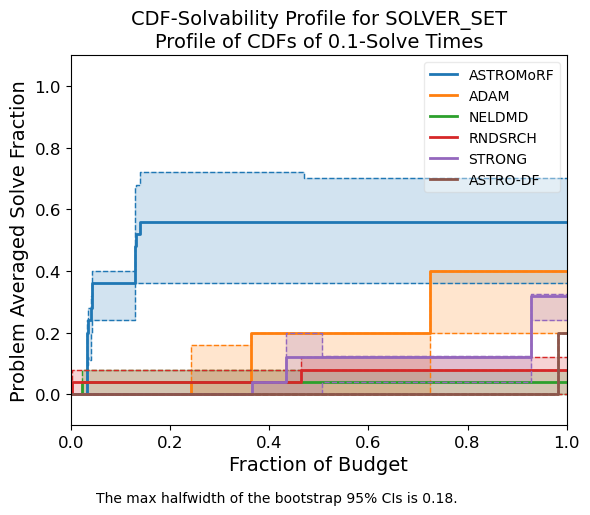

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_SAN-1_mean_prog_curve.png


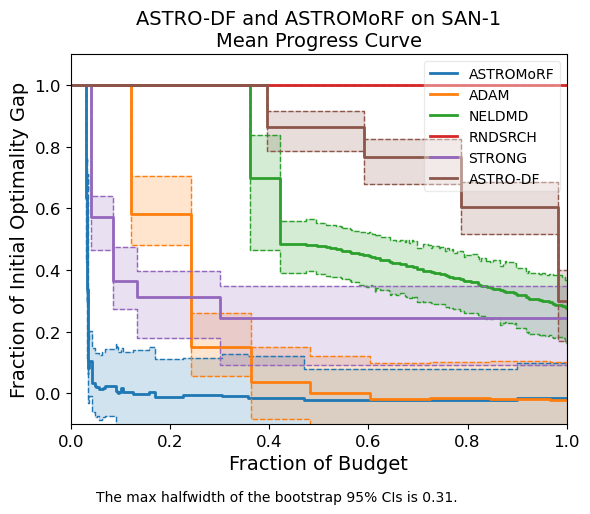

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_NETWORK-1_mean_prog_curve.png


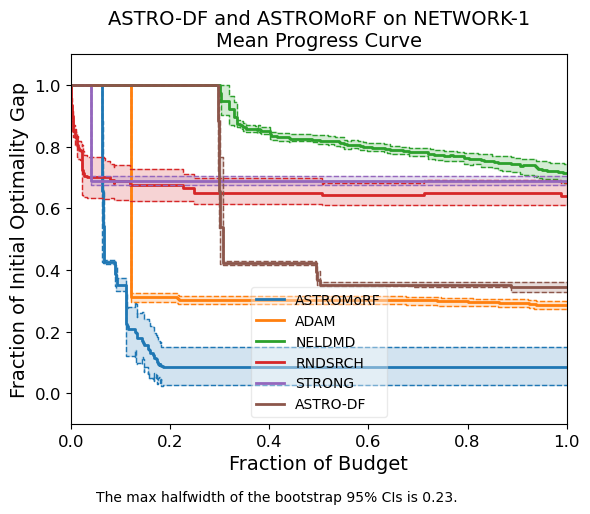

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_DYNAMNEWS-1_mean_prog_curve.png


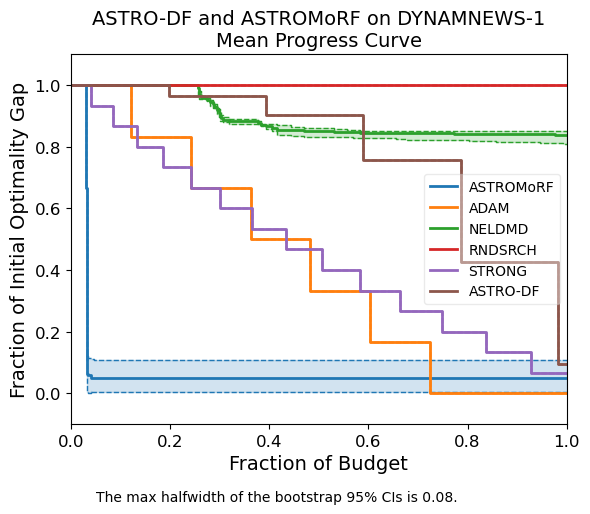

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_ROSENBROCK-1_mean_prog_curve.png


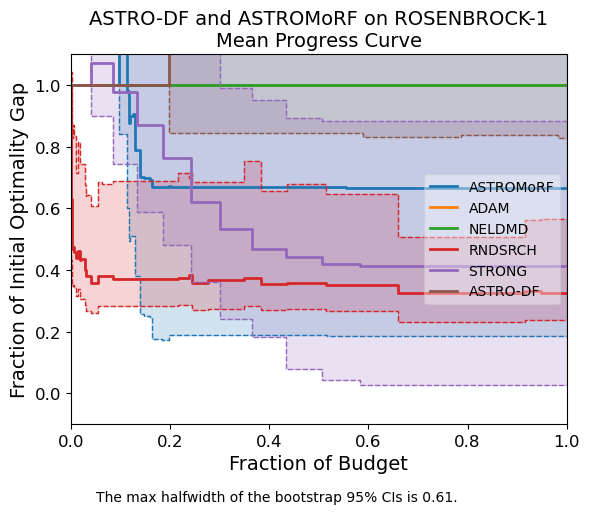

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_SSCONT-1_mean_prog_curve.png


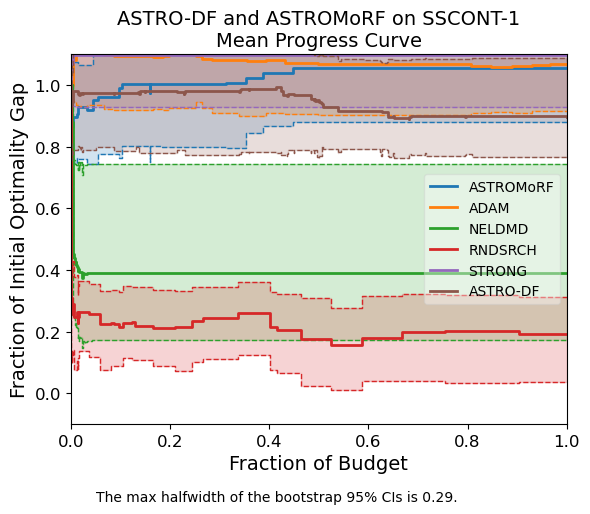

solver ASTROMoRF on problem SAN-1 has budget [49999, 49977, 49909, 49989, 49992]
solver ADAM on problem SAN-1 has budget [48270, 48270, 48270, 48270, 48270]
solver NELDMD on problem SAN-1 has budget [49980, 49980, 49980, 49980, 49980]
solver RNDSRCH on problem SAN-1 has budget [50000, 50000, 50000, 50000, 50000]
solver STRONG on problem SAN-1 has budget [18301, 21718, 21718, 18301, 18301]
solver ASTRO-DF on problem SAN-1 has budget [49980, 49980, 49980, 49980, 49980]
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_SAN-1_fn_estimates_mean.png


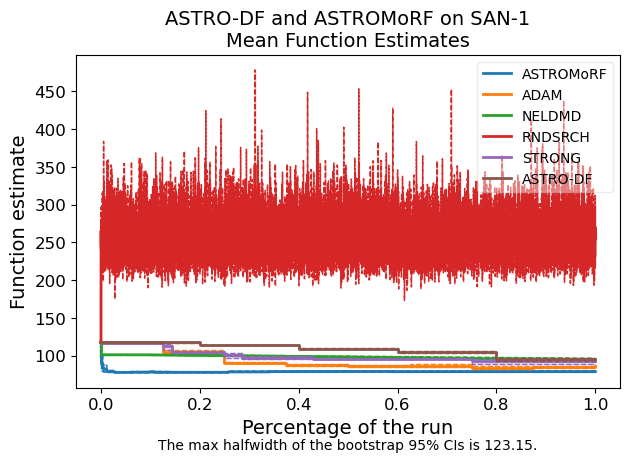

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_SAN-1_budget_history_mean.png


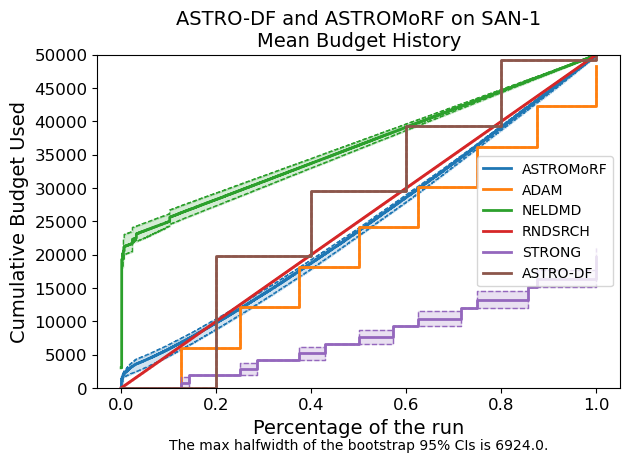

solver ASTROMoRF on problem NETWORK-1 has budget [50000, 50000, 50000, 50000, 50000]
solver ADAM on problem NETWORK-1 has budget [49200, 49860, 49290, 49350, 46890]
solver NELDMD on problem NETWORK-1 has budget [48390, 49650, 49980, 49980, 49980]
solver RNDSRCH on problem NETWORK-1 has budget [50000, 50000, 50000, 50000, 50000]
solver STRONG on problem NETWORK-1 has budget [33020, 18220, 41620, 25220, 41620]
solver ASTRO-DF on problem NETWORK-1 has budget [50000, 50000, 49974, 50000, 49962]
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_NETWORK-1_fn_estimates_mean.png


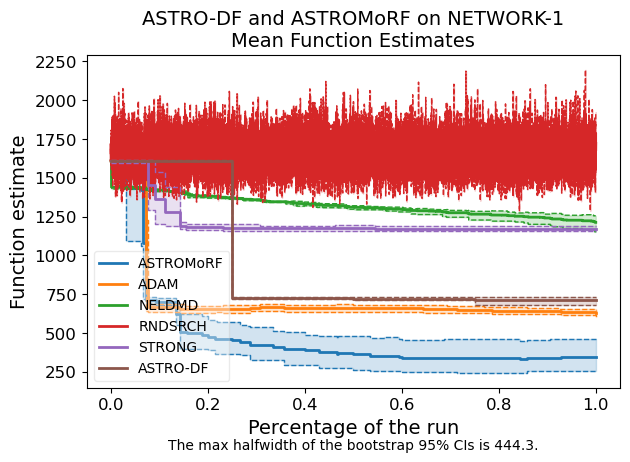

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_NETWORK-1_budget_history_mean.png


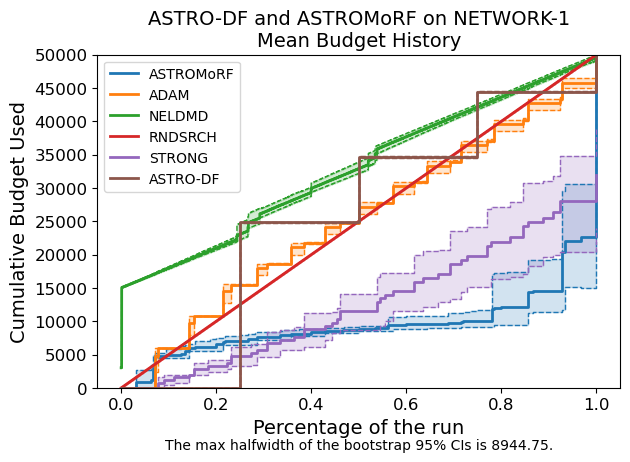

solver ASTROMoRF on problem DYNAMNEWS-1 has budget [50000, 49966, 49999, 49971, 49972]
solver ADAM on problem DYNAMNEWS-1 has budget [45300, 45300, 45300, 45300, 45300]
solver NELDMD on problem DYNAMNEWS-1 has budget [24060, 49980, 29430, 16650, 23490]
solver RNDSRCH on problem DYNAMNEWS-1 has budget [50000, 50000, 50000, 50000, 50000]
solver STRONG on problem DYNAMNEWS-1 has budget [46441, 46441, 46441, 46441, 46441]
solver ASTRO-DF on problem DYNAMNEWS-1 has budget [49980, 49980, 49980, 49980, 49980]
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_DYNAMNEWS-1_fn_estimates_mean.png


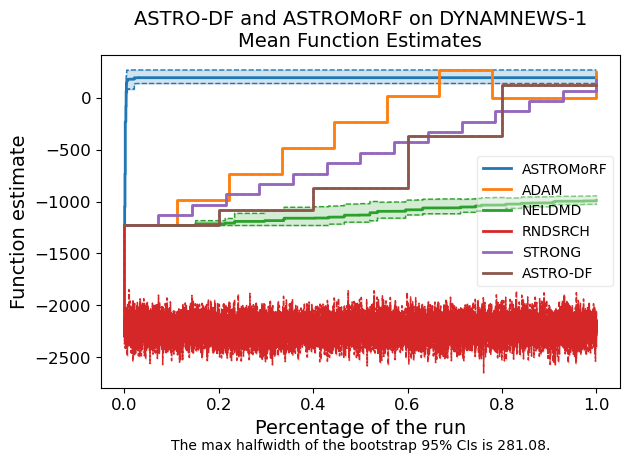

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_DYNAMNEWS-1_budget_history_mean.png


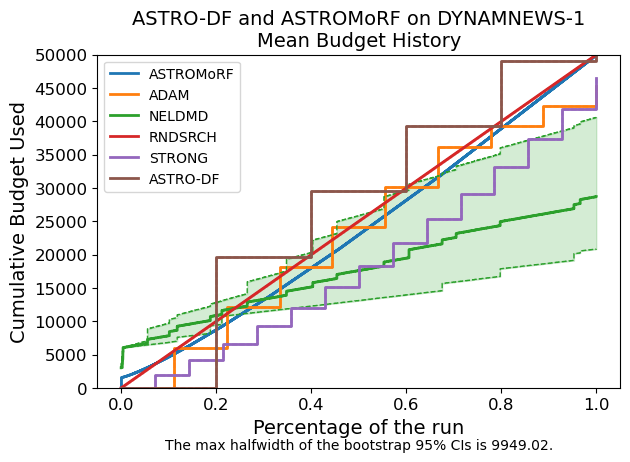

solver ASTROMoRF on problem ROSENBROCK-1 has budget [49981, 9105, 40334, 11709, 49948]
solver ADAM on problem ROSENBROCK-1 has budget [48270, 48270, 48270, 48270, 48270]
solver NELDMD on problem ROSENBROCK-1 has budget [49590, 47640, 47790, 49980, 48900]
solver RNDSRCH on problem ROSENBROCK-1 has budget [50000, 50000, 50000, 50000, 50000]
solver STRONG on problem ROSENBROCK-1 has budget [46441, 21718, 18301, 46441, 41818]
solver ASTRO-DF on problem ROSENBROCK-1 has budget [50000, 49980, 49980, 49980, 50000]
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_ROSENBROCK-1_fn_estimates_mean.png


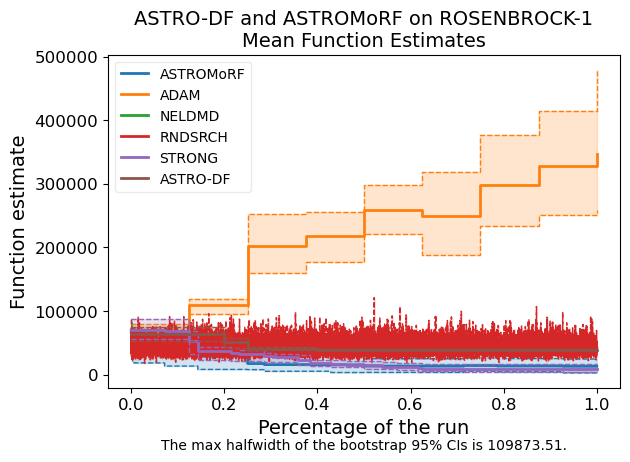

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_ROSENBROCK-1_budget_history_mean.png


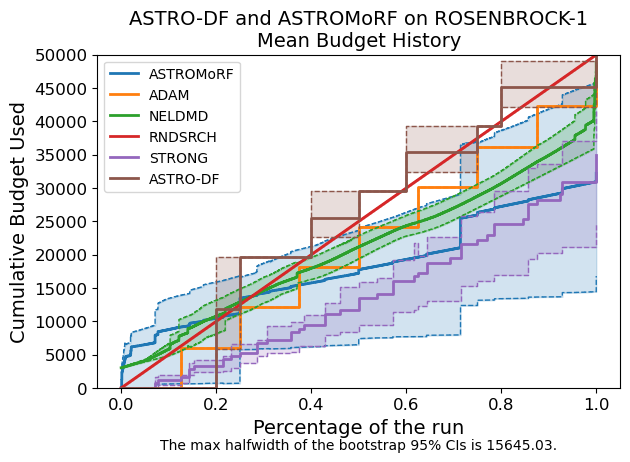

solver ASTROMoRF on problem SSCONT-1 has budget [49972, 49981, 50000, 49989, 49992]
solver ADAM on problem SSCONT-1 has budget [49980, 49980, 49980, 49980, 49980]
solver NELDMD on problem SSCONT-1 has budget [49980, 49980, 49980, 49980, 49980]
solver RNDSRCH on problem SSCONT-1 has budget [50000, 50000, 50000, 50000, 50000]
solver STRONG on problem SSCONT-1 has budget [940, 640, 465, 835, 940]
solver ASTRO-DF on problem SSCONT-1 has budget [50000, 50000, 50000, 50000, 50000]
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_SSCONT-1_fn_estimates_mean.png


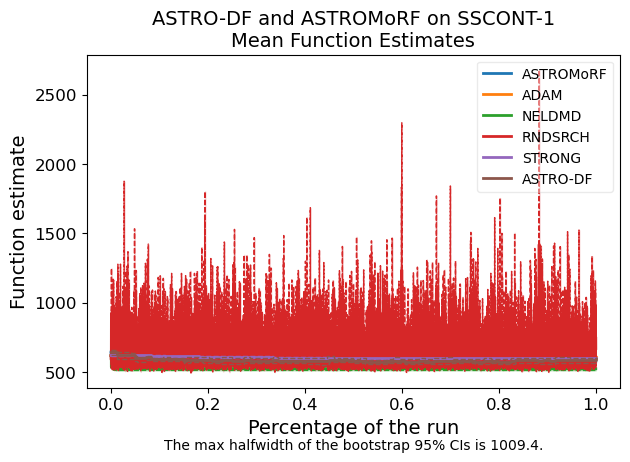

Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-01-21_10-16-22/plots/ASTRO-DF and ASTROMoRF_SSCONT-1_budget_history_mean.png


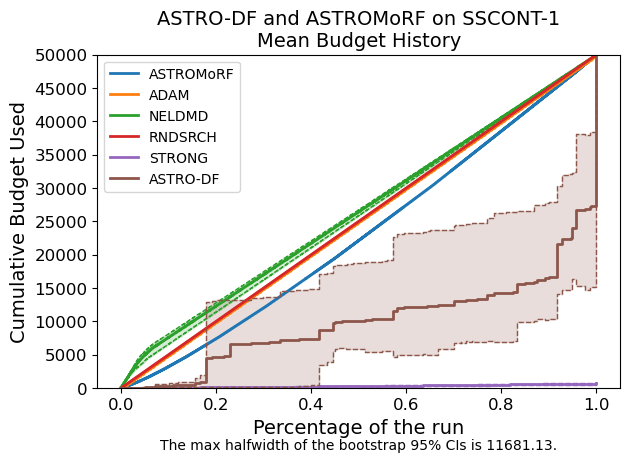

Plotting complete!


In [ ]:
# Produce basic plots.
import matplotlib.pyplot as plt
from IPython.display import Image, display

from simopt.experiment_base import PlotType, plot_solvability_profiles, plot_budget_history, plot_fn_estimates, plot_progress_curves

print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of mymetaexperiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in mymetaexperiment.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_flattened = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_flattened.append(ps_list)








def _print_path_and_display(plot_paths: list[Path]) -> None:
    for plot_path in plot_paths:
        print(f"Plot saved to {plot_path!s}")
        display(Image(filename=str(plot_path)))


_print_path_and_display(
    plot_solvability_profiles(
        experiments=mymetaexperiment.experiments, plot_type=PlotType.CDF_SOLVABILITY
    )
)


for problem in experiments_flattened:
    _print_path_and_display(
        plot_progress_curves(
            experiments=problem, 
            plot_type=PlotType.MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True,
            allow_xstar_mismatch=True
        )
    )

# mymetaexperiment.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(mymetaexperiment.experiments)
n_problems = len(mymetaexperiment.experiments[0]) if n_solvers > 0 else 0

for prob_idx in range(n_problems):
    # Collect all solvers for this problem
    solvers_for_problem = [mymetaexperiment.experiments[solver_idx][prob_idx] for solver_idx in range(n_solvers)]

    #get the terminal budget for each problem solver 
    [print(f"solver {s.solver.name} on problem {s.problem.name} has budget {[x[-1] for x in s.all_budget_history]}") for s in solvers_for_problem]

    _print_path_and_display(
        plot_fn_estimates(
            experiments=solvers_for_problem,
            plot_type=PlotType.FN_ESTIMATES_MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True,
        )
    )
    _print_path_and_display(
        plot_budget_history(
            experiments=solvers_for_problem,
            plot_type=PlotType.BUDGET_HISTORY_MEAN, 
            solver_set_name="ASTRO-DF and ASTROMoRF", 
            normalize=True
        )
    )

print("Plotting complete!")

In [ ]:
# Analyze budget per iteration for both solvers
print("=" * 80)
print("BUDGET ANALYSIS: ASTROMoRF vs ASTRO-DF")
print("=" * 80)

#flatten the experiments list into a single list
flatten_experiments = []
for solver_experiments in mymetaexperiment.experiments:
    for experiment in solver_experiments:
        flatten_experiments.append(experiment)

#in the flatten experiments list place common problems together
flatten_experiments.sort(key=lambda e: (e.problem.name, e.solver.name))

for experiment in flatten_experiments:
    solver_name = experiment.solver.name
    problem_name = experiment.problem.name
    problem_dim = experiment.problem.dim
    if solver_name.upper() == "ASTROMORF":
        subspace_dim = experiment.solver.factors.get('initial subspace dimension', 4)
    
    print(f"\n{solver_name} on {problem_name} (dim={problem_dim}):")
    print("-" * 60)
    
    for macrorep in range(experiment.n_macroreps):
        budgets = experiment.all_intermediate_budgets[macrorep]
        n_iters = len(budgets)
        
        if n_iters > 1:
            # Calculate budget spent per iteration
            budget_per_iter = [budgets[0]]  # First iteration
            for i in range(1, n_iters):
                budget_per_iter.append(budgets[i] - budgets[i-1])
            
            avg_budget_per_iter = sum(budget_per_iter) / len(budget_per_iter)
            max_budget_iter = max(budget_per_iter)
            total_budget = budgets[-1]
            
            print(f"  Macrorep {macrorep + 1}:")
            print(f"    Total iterations: {n_iters}")
            print(f"    Total budget used: {total_budget}")
            print(f"    Avg budget/iteration: {avg_budget_per_iter:.1f}")
            print(f"    Max budget in single iteration: {max_budget_iter}")
            
            # Expected design points per iteration
            if "ASTROMORF" in solver_name.upper():
                # ASTROMoRF uses 2d+1 where d is subspace dimension (default 4)
                expected_points = 2 * subspace_dim + 1
                print(f"    Expected design points/iter (2*{subspace_dim}+1): {expected_points}")
            else:  # ASTRO-DF
                expected_points = 2 * problem_dim + 1
                print(f"    Expected design points/iter (2*{problem_dim}+1): {expected_points}")
            
            print(f"    Implied avg samples/point: {avg_budget_per_iter / expected_points:.1f}")

BUDGET ANALYSIS: ASTROMoRF vs ASTRO-DF

ADAM on DYNAMNEWS-1 (dim=100):
------------------------------------------------------------
  Macrorep 1:
    Total iterations: 8
    Total budget used: 50000
    Avg budget/iteration: 6250.0
    Max budget in single iteration: 13790
    Expected design points/iter (2*100+1): 201
    Implied avg samples/point: 31.1
  Macrorep 2:
    Total iterations: 8
    Total budget used: 50000
    Avg budget/iteration: 6250.0
    Max budget in single iteration: 13790
    Expected design points/iter (2*100+1): 201
    Implied avg samples/point: 31.1
  Macrorep 3:
    Total iterations: 8
    Total budget used: 50000
    Avg budget/iteration: 6250.0
    Max budget in single iteration: 13790
    Expected design points/iter (2*100+1): 201
    Implied avg samples/point: 31.1
  Macrorep 4:
    Total iterations: 8
    Total budget used: 50000
    Avg budget/iteration: 6250.0
    Max budget in single iteration: 13790
    Expected design points/iter (2*100+1): 201
    

# ASTROMoRF Diagnostics

This section summarizes ASTROMoRF diagnostics (log files and in-memory solver state) for quick inspection. Run this after you have executed the experiment cells.

In [ ]:
import glob
import pathlib
from IPython.display import display, Markdown


def _summarize_log_file(path):
    print(f"--- {path} ---")
    try:
        with open(path, 'r') as f:
            lines = f.readlines()
    except Exception as e:
        print("Could not read file:", e)
        return
    tail = lines[-200:]
    for L in tail:
        if any(kw in L for kw in ['Adaptive subspace dimension change', 'Plateau detected', 'recommended_dimension', 'validation_by_d', 'relative_improvement', 'Iteration']):
            print(L.strip())
    changes = sum(1 for L in lines if 'Adaptive subspace dimension change' in L)
    print(f"Adaptive subspace changes (total in file): {changes}\n")


def scan_diagnostics(problems=['ROSENBROCK-1','SSCONT-1']):
    base = pathlib.Path.cwd().parent / 'Diagnostics'
    if not base.exists():
        base = pathlib.Path('Diagnostics')
    print('Diagnostics dir:', base)
    for prob in problems:
        pattern = str(base / f"**/astromorf_diagnostics_{prob}_*.txt")
        files = glob.glob(pattern, recursive=True)
        if not files:
            print(f"No diagnostics files for {prob}")
            continue
        files_sorted = sorted(files)
        print(f"Found {len(files_sorted)} files for {prob}; showing up to last 5 files summaries:\n")
        for p in files_sorted[-5:]:
            _summarize_log_file(p)


def summarize_in_memory(problems=['ROSENBROCK-1','SSCONT-1']):
    if 'mymetaexperiment' not in globals():
        print("mymetaexperiment not in globals(); run the experiment cells first to populate it.")
        return
    for solver_group in mymetaexperiment.experiments:
        for ps in solver_group:
            try:
                solver = ps.solver
                problem = ps.problem
            except Exception:
                continue
            if solver.name != 'ASTROMORF' or problem.name not in problems:
                continue
            print(f"=== In-memory: Solver={solver.name} Problem={problem.name} ===")
            print(' current d:', getattr(solver, 'd', None))
            print(' d_history (last 10):', getattr(solver, 'd_history', [])[-10:])
            print(' consecutive_unsuccessful:', getattr(solver, 'consecutive_unsuccessful', None))
            print(' recent_prediction_errors:', getattr(solver, 'recent_prediction_errors', []))
            prev = getattr(solver, 'previous_model_information', [])
            print(' previous_model_information entries:', len(prev))
            for i, info in enumerate(prev[-5:]):
                print(f"  entry {len(prev)-5+i}: recommended_dimension={info.get('recommended_dimension')}, validation_by_d={info.get('validation_by_d')}")
            print('\n')


# Run both scanners by default
scan_diagnostics()
print('\n')
summarize_in_memory()


Diagnostics dir: /Users/benjaminrees/Desktop/simopt/Diagnostics
Found 568 files for ROSENBROCK-1; showing up to last 5 files summaries:

--- /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMoRF-subspace-4_on_ROSENBROCK-1/astromorf_diagnostics_ROSENBROCK-1_2026-01-07_18-13-13_pid82369_r1301.txt ---
Adaptive subspace changes (total in file): 0

--- /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMoRF-subspace-4_on_ROSENBROCK-1/astromorf_diagnostics_ROSENBROCK-1_2026-01-07_18-13-13_pid82370_r8226.txt ---
Adaptive subspace changes (total in file): 0

--- /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMoRF-subspace-4_on_ROSENBROCK-1/astromorf_diagnostics_ROSENBROCK-1_2026-01-07_18-14-11_pid82453_r8523.txt ---
Adaptive subspace changes (total in file): 0

--- /Users/benjaminrees/Desktop/simopt/Diagnostics/ASTROMoRF-subspace-4_on_ROSENBROCK-1/astromorf_diagnostics_ROSENBROCK-1_2026-01-07_18-14-11_pid82454_r1299.txt ---
Adaptive subspace changes (total in file): 0

--- /Users/benj